# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc 
import pygenelab as pgl
import decoupler

# Get Dataset

In [3]:
# female human skeletal muscle path
FEMALE_HUMAN_SKM_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/public_datasets/SKM_multimodal_ageing/objects/tmp/myofibers_female.h5ad"

# load adata
adata = sc.read_h5ad(FEMALE_HUMAN_SKM_PATH)

# only keep OM6 and OM9
adata = pgl.subset_adata_by_obs(adata, filters={"sample": ["OM6", "OM9"]})
display(adata.obs["sample"].value_counts())

sample
OM9    40449
OM6    11429
Name: count, dtype: int64

# Get Geneset

In [4]:
metabolic_pathways = [
    "HALLMARK_FATTY_ACID_METABOLISM",
    "HALLMARK_XENOBIOTIC_METABOLISM",
    "REACTOME_PYRUVATE_METABOLISM",
    "REACTOME_PHOSPHOLIPID_METABOLISM",
    "REACTOME_GLYCOGEN_METABOLISM",
    "REACTOME_GLYCOSAMINOGLYCAN_METABOLISM",
    "WP_PURINE_METABOLISM"
]

In [ ]:
# mice all pathways path
MICE_ALL_PATHWAYS = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"

# specify pathway
pathway = "WP_PURINE_METABOLISM"

# load pathway genes
pathway_genes = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS, include_pathways=[pathway], gene_origin="human")
display(pathway_genes.head())
print(f"Number Of Genes: {len(pathway_genes)}")

,source,target
0,WP_PURINE_METABOLISM,ADA
1,WP_PURINE_METABOLISM,ADCY1
2,WP_PURINE_METABOLISM,ADCY10
3,WP_PURINE_METABOLISM,ADCY2
4,WP_PURINE_METABOLISM,ADCY3


Number Of Genes: 172


# Get Scores

In [33]:
# check if genes are in adata
pgl.check_genes_in_adata(pathway_genes, adata)

{'total_genes_checked': 172,
 'genes_found_in_adata': 162,
 'genes_missing_from_adata': 10,
 'matched_genes': ['ADA',
  'ADCY1',
  'ADCY10',
  'ADCY2',
  'ADCY3',
  'ADCY4',
  'ADCY5',
  'ADCY6',
  'ADCY7',
  'ADCY8',
  'ADCY9',
  'ADK',
  'ADPRM',
  'ADSL',
  'AK1',
  'AK2',
  'AK4',
  'AK5',
  'AK6',
  'AK7',
  'AK8',
  'AK9',
  'ALLC',
  'AMPD1',
  'AMPD2',
  'AMPD3',
  'APRT',
  'ATIC',
  'CANT1',
  'DCK',
  'DGUOK',
  'ENPP1',
  'ENPP3',
  'ENTPD1',
  'ENTPD2',
  'ENTPD3',
  'ENTPD4',
  'ENTPD5',
  'ENTPD6',
  'ENTPD8',
  'FHIT',
  'GART',
  'GDA',
  'GMPR',
  'GMPR2',
  'GMPS',
  'GUCY1A1',
  'GUCY1A2',
  'GUCY1B1',
  'GUCY1B2',
  'GUCY2C',
  'GUCY2D',
  'GUCY2F',
  'GUK1',
  'HDDC3',
  'HPRT1',
  'IMPDH1',
  'IMPDH2',
  'ITPA',
  'NME1',
  'NME2',
  'NME3',
  'NME4',
  'NME5',
  'NME6',
  'NME7',
  'NPR1',
  'NPR2',
  'NT5C',
  'NT5C1A',
  'NT5C1B',
  'NT5C2',
  'NT5E',
  'NT5M',
  'NUDT16',
  'NUDT2',
  'NUDT5',
  'NUDT9',
  'PAICS',
  'PAPSS1',
  'PAPSS2',
  'PDE10A',
  'PDE11

In [34]:
%%time

# get scores for om6
decoupler.mt.aucell(
    adata,
    pathway_genes,
    raw=False,
    verbose=True
)

2026-05-11 23:41:09 | [INFO] aucell - Running aucell
2026-05-11 23:41:09 | [INFO] Extracted omics mat with 51878 rows (observations) and 48355 columns (features)
2026-05-11 23:41:09 | [WARNING] 6429 features of mat are empty, they will be removed
2026-05-11 23:41:10 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-05-11 23:41:11 | [INFO] Network has 161 unique features and 1 unique sources
2026-05-11 23:41:11 | [INFO] aucell - calculating 1 AUCs for 41926 targets across 51878 observations, categorizing features at rank=2097
100%|██████████| 51878/51878 [00:58<00:00, 879.57it/s] 
2026-05-11 23:42:10 | [INFO] aucell - done


CPU times: user 1h 1min 50s, sys: 1.33 s, total: 1h 1min 51s
Wall time: 1min


In [35]:
adata.obs[pathway] = adata.obsm["score_aucell"][pathway].copy()
display(adata.obs[pathway].head(10))

CELL2785_N1_1_1_6_1    0.065908
CELL1152_N1_1_1_6_1    0.059826
CELL312_N2_1_1_6_1     0.061868
CELL2659_N1_1_1_6_1    0.076719
CELL303_N2_1_1_6_1     0.060118
CELL591_N2_1_1_6_1     0.075224
CELL736_N2_1_1_6_1     0.073628
CELL531_N2_1_1_6_1     0.068080
CELL299_N2_1_1_6_1     0.049424
CELL685_N2_1_1_6_1     0.052817
Name: WP_PURINE_METABOLISM, dtype: float64

In [36]:
# get scores per group 
group_score_df = pgl.prepare_group_score_df(adata, group_col="sample", value_col=pathway, dropna=True)
display(group_score_df.head())

,sample,WP_PURINE_METABOLISM
0,OM6,0.065908
1,OM6,0.059826
2,OM6,0.061868
3,OM6,0.076719
4,OM6,0.060118


In [37]:
# get summary of scores per group
pgl.summarize_score_by_group(group_score_df, group_col="sample", score_col=pathway)

,sample,count,mean,median,std,min,max
0,OM6,11429,0.05634,0.056286,0.012662,0.010823,0.106958
1,OM9,40449,0.05859,0.058538,0.012203,0.012321,0.115024


# Calculate Cliffs Delta

In [ ]:
metabolic_pathways = [
    "HALLMARK_FATTY_ACID_METABOLISM",
    "HALLMARK_XENOBIOTIC_METABOLISM",
    "REACTOME_PYRUVATE_METABOLISM",
    "REACTOME_PHOSPHOLIPID_METABOLISM",
    "REACTOME_GLYCOGEN_METABOLISM",
    "REACTOME_GLYCOSAMINOGLYCAN_METABOLISM",
    "WP_PURINE_METABOLISM"
]



# Plot

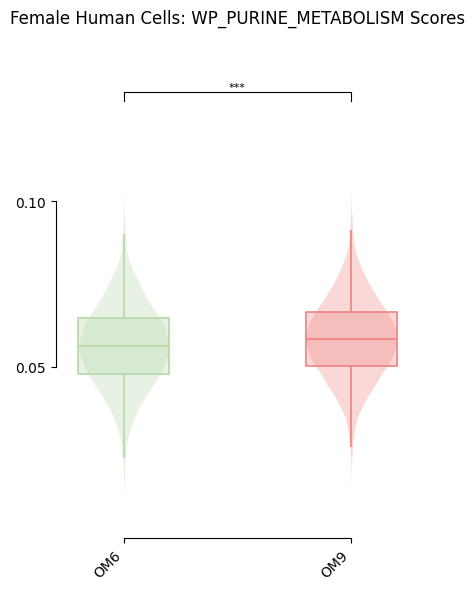

<Figure size 640x480 with 0 Axes>

In [ ]:
# # choose order
# sample_order = ["OM6", "OM9"]

# # palette keys must match age_label values
# palette = {
#     "OM6": "#B6D7A8",
#     "OM9": "#F08080"
# }

# # plot violin box plot
# fig_violin_box = pgl.plot_violin_box_combo(group_score_df,
#                                            x_var="sample",
#                                            y_var=pathway,
#                                            title=f"Female Human Cells: {pathway} Scores",
#                                            palette=palette,
#                                            x_ticks=sample_order,
#                                            show_scatter=False)

# display(fig_violin_box)

In [ ]:
# # subset OM6 and get gene correlation
# adata_om6 = pgl.subset_adata_by_obs(adata, filters={"sample": "OM6"})
# ranked_genes_om6 = pgl.compute_gene_correlation_against_score(adata_om6, 
#                                                               pgl.get_pathway_genes(pathway_genes, pathway), 
#                                                               score=pathway)
# display(ranked_genes_om6.head())

# # subset OM9 and get gene correlation
# adata_om9 = pgl.subset_adata_by_obs(adata, filters={"sample": "OM9"})
# ranked_genes_om9 = pgl.compute_gene_correlation_against_score(adata_om9, 
#                                                               pgl.get_pathway_genes(pathway_genes, pathway), 
#                                                               score=pathway)
# display(ranked_genes_om9.head())

,gene,spearman_corr,rank
0,AMPD1,0.257100,1
1,FHIT,0.220112,2
2,GMPR,0.217051,3
3,PDE8A,0.214244,4
4,PNPT1,0.211019,5


,gene,spearman_corr,rank
0,ADCY9,0.235277,1
1,ADCY2,0.232033,2
2,PDE11A,0.219056,3
3,NT5C2,0.208345,4
4,ADK,0.205311,5


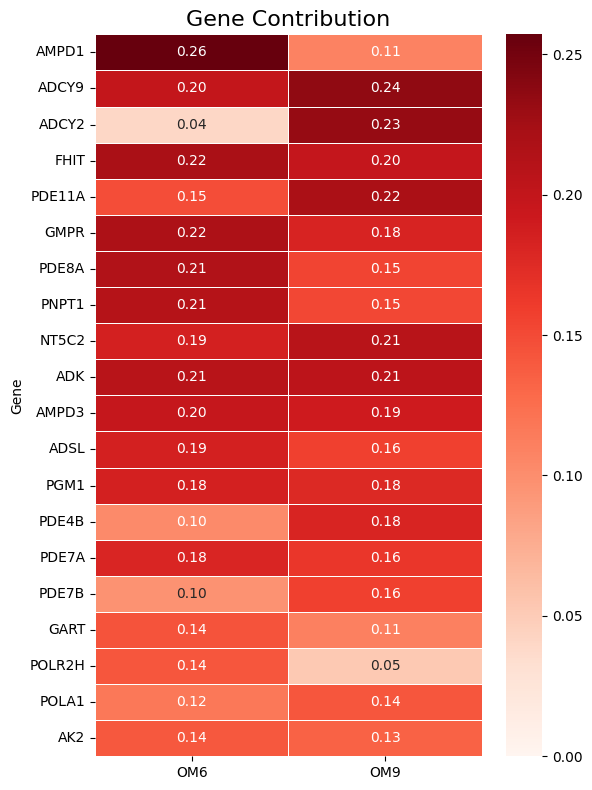

In [ ]:
# gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
#     {"OM6": ranked_genes_om6,
#      "OM9": ranked_genes_om9},
#      title="Gene Contribution"
# )

In [ ]:
from pathlib import Path

# output folder
output_dir = Path("Output")
output_dir.mkdir(parents=True, exist_ok=True)

# figures to save separately
figures_to_save = {
    "Violin_Box": fig_violin_box,
    "Gene_Contribution_Heatmap": fig_gene_contribution_heatmap
}

# save each figure as svg and png
for plot_type, fig in figures_to_save.items():

    # create output paths
    svg_path = output_dir / f"OM6_OM9_{pathway}_{plot_type}_SVG.svg"
    png_path = output_dir / f"OM6_OM9_{pathway}_{plot_type}_PNG.png"

    # save editable svg
    pgl.save_editable_svg(
        fig=fig,
        output_path=svg_path
    )

    # save png
    pgl.save_fig_as_png(
        fig=fig,
        output_path=png_path
    )

    print(f"saved: {svg_path}")
    print(f"saved: {png_path}")

saved: Output/OM6_OM9_WP_PURINE_METABOLISM_Violin_Box_SVG.svg
saved: Output/OM6_OM9_WP_PURINE_METABOLISM_Violin_Box_PNG.png
saved: Output/OM6_OM9_WP_PURINE_METABOLISM_Gene_Contribution_Heatmap_SVG.svg
saved: Output/OM6_OM9_WP_PURINE_METABOLISM_Gene_Contribution_Heatmap_PNG.png


In [42]:
# # combine figures and save image
# SAVE_PATH = f"Output/OM6_OM9_{pathway}.png"
# pgl.combine_two_figures(fig_violin_box, fig_gene_contribution_heatmap, save_path=SAVE_PATH)